<a href="https://colab.research.google.com/github/brunogk/An-lise-de-Emiss-es-de-CO-com-foco-ambiental-e-transi-o-energ-tica/blob/main/An%C3%A1lise_de_Emiss%C3%B5es_de_CO%E2%82%82_com_foco_ambiental_e_transi%C3%A7%C3%A3o_energ%C3%A9tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análise de Emissões de CO₂ com foco ambiental e transição energética

# Projeto de Análise de Dados Ambientais
## Emissões de CO₂, intensidade de carbono e indicadores energéticos

### Objetivo
Analisar a evolução das emissões de CO₂ em países selecionados, comparando indicadores como emissões totais, emissões per capita, intensidade de carbono e participação de fontes energéticas, com foco em interpretação ambiental.

### Perguntas orientadoras
- Como as emissões evoluíram nos principais países analisados?
- Quais países apresentam maior emissão per capita?
- Há sinais de desacoplamento entre crescimento econômico e emissões?
- Como variáveis energéticas ajudam a interpretar o comportamento das emissões?

### Fonte dos dados
- Our World in Data (OWID): base pública de emissões e energia

In [ ]:
# =====================================
# 1. SETUP
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


**Coleta dos dados**

In [ ]:
# =====================================
# 2. COLETA DE DADOS
# =====================================

url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"

df_raw = pd.read_csv(url)

print("Dimensão da base bruta:", df_raw.shape)
df_raw.head()

Dimensão da base bruta: (50411, 79)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Inspecionar os dados de forma inicial

In [ ]:
# =====================================
# 3. INSPEÇÃO INICIAL
# =====================================

print("Primeiras colunas da base:")
print(df_raw.columns.tolist()[:50])

print("\nTipos de dados:")
print(df_raw.dtypes.head(20))

print("\nAmostra de colunas importantes:")
colunas_exemplo = [c for c in ['country', 'iso_code', 'year', 'co2', 'co2_per_capita', 'gdp', 'population'] if c in df_raw.columns]
display(df_raw[colunas_exemplo].head())

Primeiras colunas da base:
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', '

,country,iso_code,year,co2,co2_per_capita,gdp,population
0,Afghanistan,AFG,1750,NaN,NaN,NaN,2802560.0
1,Afghanistan,AFG,1751,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1752,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,1753,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,1754,NaN,NaN,NaN,NaN


Limpeza dos dados que aparecem com NaN

In [ ]:
# =====================================
# 4. LIMPEZA DE DADOS
# =====================================

df = df_raw.copy()

# Remover linhas sem código ISO
if 'iso_code' in df.columns:
    df = df[df['iso_code'].notna()]

# Remover agregados como World, Asia, Europe, etc.
if 'iso_code' in df.columns:
    df = df[~df['iso_code'].astype(str).str.startswith('OWID')]

# Filtrar período mais recente e com melhor cobertura
if 'year' in df.columns:
    df = df[df['year'] >= 2000]

# Garantir existência da variável principal
if 'co2' in df.columns:
    df = df[df['co2'].notna()]

print("Dimensão após limpeza:", df.shape)
df.head()

Dimensão após limpeza: (5375, 79)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
250,Afghanistan,2000,AFG,20130334.0,1.128379e+10,0.010,0.001,1.047,-0.045,-4.078,1.112,-0.830,-42.735,0.055,0.099,0.210,0.052,0.093,0.198,0.004,0.000,NaN,NaN,NaN,1.969,72.449,350.580,11.851,5.934,13.897,771.560,38.798,NaN,262.680,0.469,0.022,0.001,0.224,0.011,0.129,0.795,0.065,0.003,9.724,0.483,3.222,0.160,0.788,0.039,NaN,NaN,5.288,0.001,0.004,0.004,0.000,0.011,0.007,0.019,0.002,0.053,0.011,0.100,0.011,NaN,0.006,0.005,0.001,0.008,NaN,0.078,0.0,0.001,0.001,0.0,16.009,2.603,NaN,NaN
251,Afghanistan,2001,AFG,20284303.0,1.102127e+10,0.007,0.000,1.069,0.022,2.098,1.935,0.823,73.952,0.095,0.176,0.530,0.053,0.097,0.293,0.070,0.003,NaN,NaN,NaN,1.975,73.519,352.515,11.921,5.956,14.106,772.425,39.560,NaN,179.892,0.331,0.022,0.001,0.209,0.010,0.133,0.734,0.866,0.043,8.387,0.413,2.853,0.141,0.762,0.038,NaN,NaN,3.649,0.001,0.004,0.006,0.001,0.010,0.007,0.019,0.002,0.051,0.011,0.100,0.011,NaN,0.007,0.004,0.016,0.007,NaN,0.077,0.0,0.001,0.001,0.0,14.895,2.701,NaN,NaN
252,Afghanistan,2002,AFG,21378123.0,1.880487e+10,0.011,0.001,1.341,0.272,25.439,6.391,4.456,230.283,0.299,0.340,1.920,0.063,0.071,0.403,0.055,0.003,NaN,NaN,NaN,1.986,74.860,358.906,11.976,5.956,14.652,777.475,40.289,NaN,155.695,0.177,0.000,0.000,0.546,0.026,0.142,0.937,5.050,0.236,10.375,0.485,3.299,0.154,0.729,0.034,NaN,NaN,3.328,0.001,0.005,0.020,0.001,0.010,0.007,0.019,0.002,0.050,0.011,0.100,0.010,NaN,0.000,0.011,0.083,0.007,NaN,0.077,0.0,0.001,0.001,0.0,20.037,3.044,NaN,NaN
253,Afghanistan,2003,AFG,22733053.0,2.107434e+10,0.010,0.000,1.560,0.219,16.302,6.169,-0.222,-3.470,0.271,0.293,1.555,0.069,0.074,0.393,0.092,0.004,NaN,NaN,NaN,1.996,76.419,365.075,12.067,5.956,15.117,782.085,41.282,NaN,174.558,0.188,0.000,0.000,0.465,0.020,0.147,0.914,4.610,0.203,10.687,0.470,3.434,0.151,0.993,0.044,NaN,NaN,3.968,0.001,0.006,0.018,0.001,0.010,0.007,0.019,0.002,0.049,0.011,0.099,0.010,NaN,0.000,0.009,0.063,0.009,NaN,0.076,0.0,0.001,0.001,0.0,20.769,3.349,NaN,NaN
254,Afghanistan,2004,AFG,23560656.0,2.233257e+10,0.010,0.000,1.237,-0.322,-20.673,3.636,-2.533,-41.059,0.154,0.163,0.978,0.053,0.055,0.333,0.092,0.004,NaN,NaN,NaN,2.006,77.657,368.711,12.159,5.956,15.344,784.484,42.191,NaN,157.758,0.166,0.000,0.000,0.227,0.010,0.131,0.804,2.399,0.102,10.651,0.452,3.412,0.145,0.909,0.039,NaN,NaN,3.717,0.001,0.004,0.010,0.001,0.009,0.007,0.019,0.002,0.047,0.01

In [ ]:
# =====================================
# 5. RECORTE ANALÍTICO
# =====================================

paises = ['Brazil', 'United States', 'China', 'India', 'Germany']

if 'country' in df.columns:
    df = df[df['country'].isin(paises)].copy()

print("Países presentes no recorte:")
print(df['country'].unique())

print("\nPeríodo disponível:")
print(df['year'].min(), "até", df['year'].max())

Países presentes no recorte:
['Brazil' 'China' 'Germany' 'India' 'United States']

Período disponível:
2000 até 2024


Seleção robusta de colunas

Esse bloco corrige o erro que você teve com colunas ausentes.

In [ ]:
# =====================================
# 6. SELEÇÃO DE VARIÁVEIS
# =====================================

cols_desejadas = [
    'country',
    'year',
    'co2',
    'co2_per_capita',
    'gdp',
    'population',
    'energy_per_capita',
    'renewables_share_energy',
    'coal_share_energy',
    'primary_energy_consumption',
    'carbon_intensity_elec'
]

cols_existentes = [c for c in cols_desejadas if c in df.columns]
cols_ausentes = [c for c in cols_desejadas if c not in df.columns]

df = df[cols_existentes].copy()

print("Colunas disponíveis:")
print(cols_existentes)

print("\nColunas ausentes:")
print(cols_ausentes)

df.head()

Colunas disponíveis:
['country', 'year', 'co2', 'co2_per_capita', 'gdp', 'population', 'energy_per_capita', 'primary_energy_consumption']

Colunas ausentes:
['renewables_share_energy', 'coal_share_energy', 'carbon_intensity_elec']


,country,year,co2,co2_per_capita,gdp,population,energy_per_capita,primary_energy_consumption
7188,Brazil,2000,340.183,1.955,1.739728e+12,174018278.0,13586.246,2364.255
7189,Brazil,2001,346.166,1.963,1.785513e+12,176301201.0,13068.835,2304.051
7190,Brazil,2002,347.765,1.948,1.861742e+12,178503485.0,13173.609,2351.535
7191,Brazil,2003,344.645,1.908,1.904933e+12,180622688.0,13211.707,2386.334
7192,Brazil,2004,361.434,1.979,2.038448e+12,182675144.0,13703.958,2503.373


In [ ]:
# =====================================
# 7. DIAGNÓSTICO DE QUALIDADE DOS DADOS
# =====================================

missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

diagnostico_missing = pd.DataFrame({
    'faltantes_absolutos': missing_abs,
    'faltantes_percentual': missing_pct
})

display(diagnostico_missing)

,faltantes_absolutos,faltantes_percentual
gdp,10,8.0
country,0,0.0
co2,0,0.0
year,0,0.0
co2_per_capita,0,0.0
population,0,0.0
energy_per_capita,0,0.0
primary_energy_consumption,0,0.0


In [ ]:
# =====================================
# 8. FEATURE ENGINEERING
# =====================================

df = df.sort_values(['country', 'year']).copy()

# CO2 por PIB
if {'co2', 'gdp'}.issubset(df.columns):
    df['co2_por_pib'] = df['co2'] / df['gdp']

# variação percentual anual de CO2
if 'co2' in df.columns:
    df['var_pct_co2'] = df.groupby('country')['co2'].pct_change() * 100

# média móvel de 3 anos
if 'co2' in df.columns:
    df['co2_mm3'] = df.groupby('country')['co2'].transform(lambda x: x.rolling(3).mean())

# crescimento populacional anual
if 'population' in df.columns:
    df['var_pct_pop'] = df.groupby('country')['population'].pct_change() * 100

display(df.head(10))

,country,year,co2,co2_per_capita,gdp,population,energy_per_capita,primary_energy_consumption,co2_por_pib,var_pct_co2,co2_mm3,var_pct_pop
7188,Brazil,2000,340.183,1.955,1.739728e+12,174018278.0,13586.246,2364.255,1.955380e-10,NaN,NaN,NaN
7189,Brazil,2001,346.166,1.963,1.785513e+12,176301201.0,13068.835,2304.051,1.938748e-10,1.758759,NaN,1.311887
7190,Brazil,2002,347.765,1.948,1.861742e+12,178503485.0,13173.609,2351.535,1.867955e-10,0.461917,344.704667,1.249160
7191,Brazil,2003,344.645,1.908,1.904933e+12,180622688.0,13211.707,2386.334,1.809224e-10,-0.897158,346.192000,1.187205
7192,Brazil,2004,361.434,1.979,2.038448e+12,182675144.0,13703.958,2503.373,1.773084e-10,4.871389,351.281333,1.136322
7193,Brazil,2005,364.371,1.973,2.129215e+12,184688101.0,13910.277,2569.063,1.711293e-10,0.812596,356.816667,1.101933
7194,Brazil,2006,368.871,1.976,2.240805e+12,186653099.0,14152.363,2641.583,1.646154e-10,1.235005,364.892000,1.063955
7195,Brazil,2007,390.573,2.071,2.405627e+12,188552311.0,14905.908,2810.543,1.623581e-10,5.883358,374.605000,1.017509
7196,Brazil,2008,412.638,2.168,2.559843e+12,190367297.0,15424.676,2936.354,1.611966e-10,5.649392,390.694000,0.962590
7197,Brazil,2009,389.775,2.029,2.589568e+12,192079958.0,15230.740,2925.520,1.505174e-10,-5.540692,397.662000,0.899661


Estatísticas descritivas

In [ ]:
# =====================================
# 9. ESTATÍSTICAS DESCRITIVAS
# =====================================

display(df.describe(include='all'))

,country,year,co2,co2_per_capita,gdp,population,energy_per_capita,primary_energy_consumption,co2_por_pib,var_pct_co2,co2_mm3,var_pct_pop
count,125,125.000000,125.000000,125.000000,1.150000e+02,1.250000e+02,125.000000,125.000000,1.150000e+02,120.000000,115.000000,120.000000
unique,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Brazil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2012.000000,3441.998464,7.439928,8.571531e+12,6.455433e+08,34541.137696,14147.955952,3.337381e-10,1.880043,3452.051835,0.722662
std,NaN,7.240121,3367.395762,6.092565,6.604290e+12,5.592481e+08,28172.479994,12857.412392,1.540473e-10,5.142173,3347.136076,0.494361
min,NaN,2000.000000,340.183000,0.929000,1.739728e+12,8.083092e+07,3470.525000,2304.051000,1.505174e-10,-11.091978,344.704667,-0.493776
25%,NaN,2006.000000,758.771000,2.071000,3.091962e+12,1.866531e+08,13211.707000,3731.718000,2.105839e-10,-1.373040,765.561500,0.414848
50%,NaN,2012.000000,1926.986000,6.943000,5.720693e+12,3.171153e+08,23821.602000,6937.768000,3.086505e-10,1.729025,1896.006000,0.779105
75%,NaN,2018.000000,5531.385000,10.578000,1.443637e+13,1.302100e+09,48509.781000,25956.828000,4.094090e-10,5.192974,5539.002833,1.000935


Evolução das emissões totais

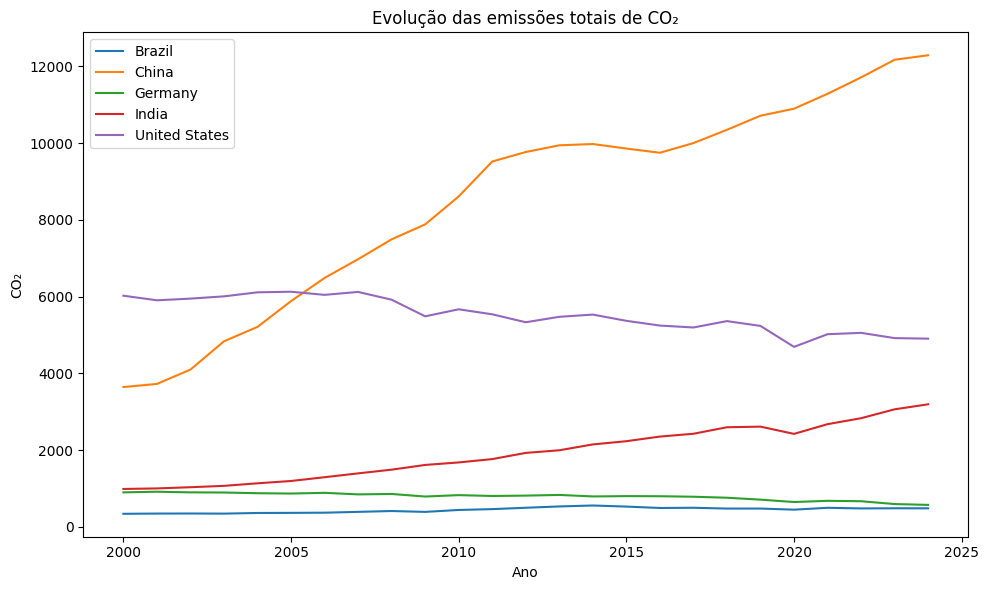

In [ ]:
# =====================================
# 10. EMISSÕES TOTAIS DE CO2
# =====================================

if {'country', 'year', 'co2'}.issubset(df.columns):
    plt.figure(figsize=(10, 6))

    for pais in df['country'].unique():
        temp = df[df['country'] == pais]
        plt.plot(temp['year'], temp['co2'], label=pais)

    plt.title('Evolução das emissões totais de CO₂')
    plt.xlabel('Ano')
    plt.ylabel('CO₂')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("As colunas necessárias para este gráfico não estão disponíveis.")

Emissão per capita

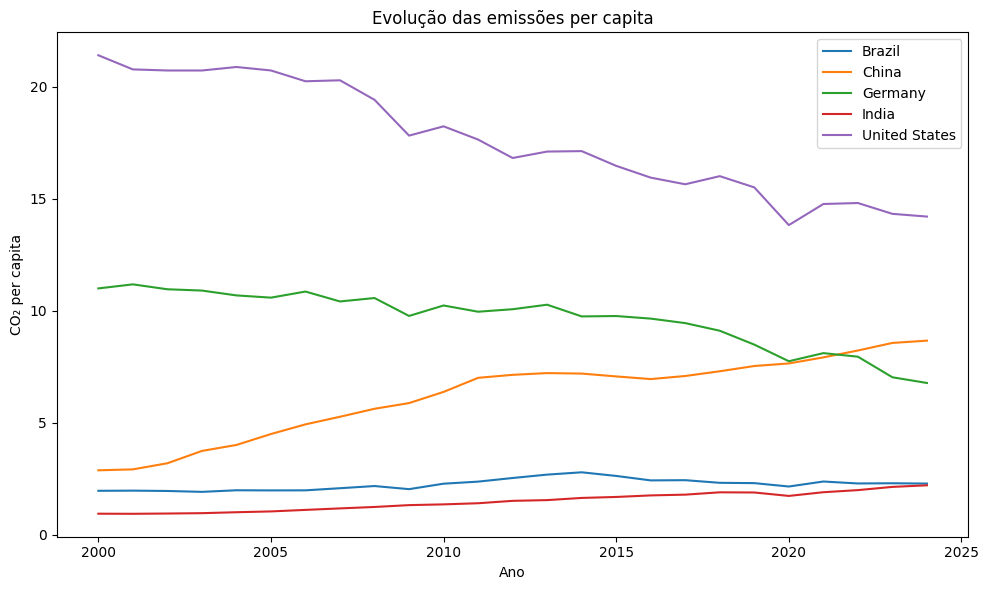

In [ ]:
# =====================================
# 11. EMISSÕES PER CAPITA
# =====================================

if {'country', 'year', 'co2_per_capita'}.issubset(df.columns):
    plt.figure(figsize=(10, 6))

    for pais in df['country'].unique():
        temp = df[df['country'] == pais]
        plt.plot(temp['year'], temp['co2_per_capita'], label=pais)

    plt.title('Evolução das emissões per capita')
    plt.xlabel('Ano')
    plt.ylabel('CO₂ per capita')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("A coluna 'co2_per_capita' não está disponível.")

Intensidade de carbono por PIB

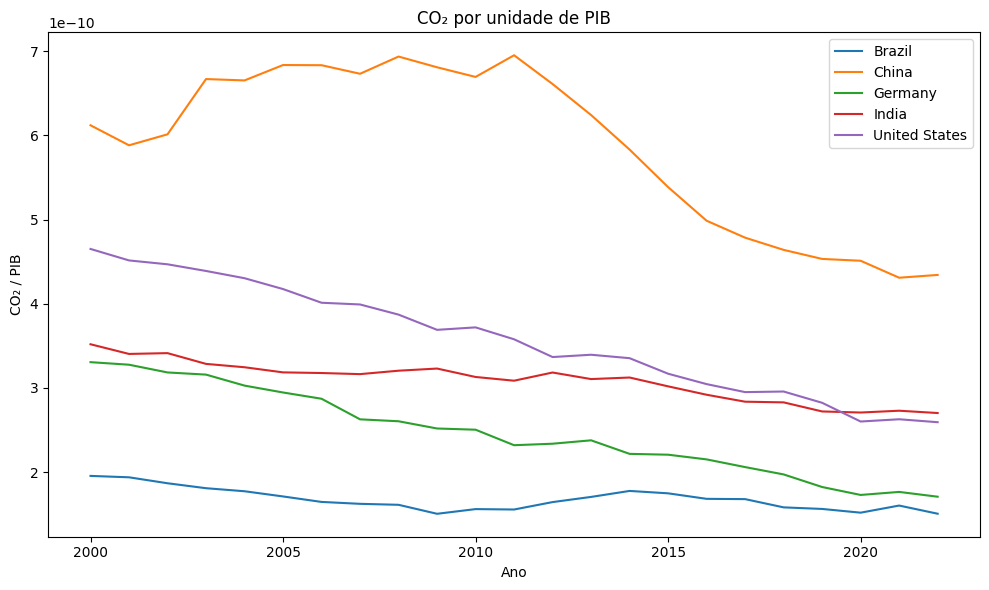

In [ ]:
# =====================================
# 12. INTENSIDADE DE CARBONO
# =====================================

if {'country', 'year', 'co2_por_pib'}.issubset(df.columns):
    plt.figure(figsize=(10, 6))

    for pais in df['country'].unique():
        temp = df[df['country'] == pais]
        plt.plot(temp['year'], temp['co2_por_pib'], label=pais)

    plt.title('CO₂ por unidade de PIB')
    plt.xlabel('Ano')
    plt.ylabel('CO₂ / PIB')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("A variável 'co2_por_pib' não está disponível.")

In [ ]:
# =====================================
# 17. RECORTE DO ÚLTIMO ANO
# =====================================

if {'country', 'year'}.issubset(df.columns):
    ultimo_ano = df['year'].max()
    df_ultimo = df[df['year'] == ultimo_ano].copy()

    print("Último ano disponível:", ultimo_ano)
    display(df_ultimo)

Último ano disponível: 2024


,country,year,co2,co2_per_capita,gdp,population,energy_per_capita,primary_energy_consumption,co2_por_pib,var_pct_co2,co2_mm3,var_pct_pop
7212,Brazil,2024,483.012,2.278,NaN,2.119986e+08,18486.229,3919.054,NaN,-0.202483,482.354000,0.406285
9933,China,2024,12289.037,8.658,NaN,1.419321e+09,34514.457,48987.102,NaN,0.961452,12057.618000,-0.229417
18319,Germany,2024,572.319,6.769,NaN,8.455223e+07,37792.512,3195.441,NaN,-3.612029,611.309333,0.004732
21762,India,2024,3193.478,2.201,NaN,1.450936e+09,7812.928,11336.057,NaN,4.268117,3029.122000,0.894685
48007,United States,2024,4904.120,14.197,NaN,3.454266e+08,76799.570,26528.611,NaN,-0.290480,4959.310000,0.567501


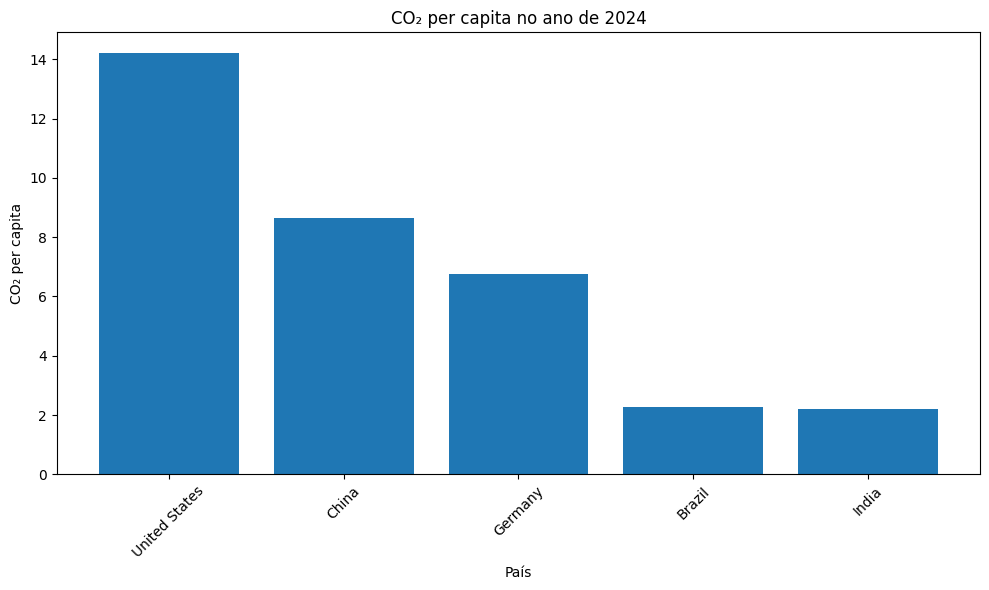

In [ ]:
# =====================================
# 18. COMPARAÇÃO ENTRE PAÍSES NO ÚLTIMO ANO
# =====================================

if {'country', 'co2_per_capita', 'year'}.issubset(df.columns):
    ultimo_ano = df['year'].max()
    df_ultimo = df[df['year'] == ultimo_ano].copy()

    df_ultimo = df_ultimo.sort_values('co2_per_capita', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.bar(df_ultimo['country'], df_ultimo['co2_per_capita'])
    plt.title(f'CO₂ per capita no ano de {ultimo_ano}')
    plt.xlabel('País')
    plt.ylabel('CO₂ per capita')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível montar o gráfico do último ano.")

## Interpretação dos resultados

## Principais achados
- Países com forte base industrial e energética fóssil tendem a apresentar maiores emissões totais.
- A análise per capita ajuda a corrigir distorções causadas pelo tamanho populacional.
- A intensidade de carbono por PIB permite avaliar se há desacoplamento entre crescimento econômico e emissões.
- Indicadores energéticos ajudam a explicar diferenças estruturais entre os países.
## Análise dos dados
- China e Índia tendem a apresentar crescimento importante nas emissões totais em função de expansão econômica e demanda energética.
- Alemanha tende a mostrar trajetória mais controlada ou de redução relativa em alguns indicadores.
- O Brasil tende a ter comportamento diferente dos grandes emissores fósseis devido à maior participação relativa de renováveis, embora isso não elimine problemas ambientais mais amplos.
- Os Estados Unidos costumam apresentar emissões per capita elevadas, ainda que com sinais de estabilização em alguns períodos.


Este projeto demonstrou a construção de um fluxo analítico em Python com dados reais e públicos, envolvendo:
- aquisição de dados
- limpeza e validação
- análise exploratória
- criação de indicadores
- interpretação ambiental orientada por dados

Além da análise das emissões, o projeto evidencia competências importantes para atuação em análise de dados:
- uso de pandas para tratamento de dados reais
- construção de gráficos com matplotlib
- tratamento de colunas ausentes e valores faltantes
- leitura crítica de indicadores ambientais

In [ ]:
# =====================================
# 21. EXPORTAÇÃO DA BASE TRATADA
# =====================================

df.to_csv("base_tratada_emissoes.csv", index=False)
print("Base tratada exportada com sucesso.")

Base tratada exportada com sucesso.


In [ ]:
from google.colab import files

df.to_csv("base_tratada_emissoes.csv", index=False)

files.download("base_tratada_emissoes.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df.columns.tolist())
print(df.head())
print(df.shape)

['country', 'year', 'co2', 'co2_per_capita', 'gdp', 'population', 'energy_per_capita', 'primary_energy_consumption', 'co2_por_pib', 'var_pct_co2', 'co2_mm3', 'var_pct_pop']
     country  year      co2  co2_per_capita           gdp   population  energy_per_capita  primary_energy_consumption   co2_por_pib  var_pct_co2     co2_mm3  var_pct_pop
7188  Brazil  2000  340.183           1.955  1.739728e+12  174018278.0          13586.246                    2364.255  1.955380e-10          NaN         NaN          NaN
7189  Brazil  2001  346.166           1.963  1.785513e+12  176301201.0          13068.835                    2304.051  1.938748e-10     1.758759         NaN     1.311887
7190  Brazil  2002  347.765           1.948  1.861742e+12  178503485.0          13173.609                    2351.535  1.867955e-10     0.461917  344.704667     1.249160
7191  Brazil  2003  344.645           1.908  1.904933e+12  180622688.0          13211.707                    2386.334  1.809224e-10    -0.897158  3